# Imports

In [98]:
sys.path.append(os.path.abspath('../'))

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_silver_data

# Carregamento dos dados

In [99]:
df = load_silver_data()

df['olist_orders_dataset'].head()

Buscando arquivos em: /home/raphael/Documents/1Raphael/Programs/Ecomerce/BigDataECommerce/data/silver
 -> olist_sellers_dataset carregado. (3095 linhas)
 -> olist_order_items_dataset carregado. (112545 linhas)
 -> olist_geolocation_dataset carregado. (1000121 linhas)
 -> olist_order_reviews_dataset carregado. (98410 linhas)
 -> product_category_name_translation carregado. (72 linhas)
 -> olist_customers_dataset carregado. (99441 linhas)
 -> olist_order_payments_dataset carregado. (103877 linhas)
 -> olist_products_dataset carregado. (32946 linhas)
 -> olist_orders_dataset carregado. (99441 linhas)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,is_delivered,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,True,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,True,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,True,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,True,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,True,False


# Insights

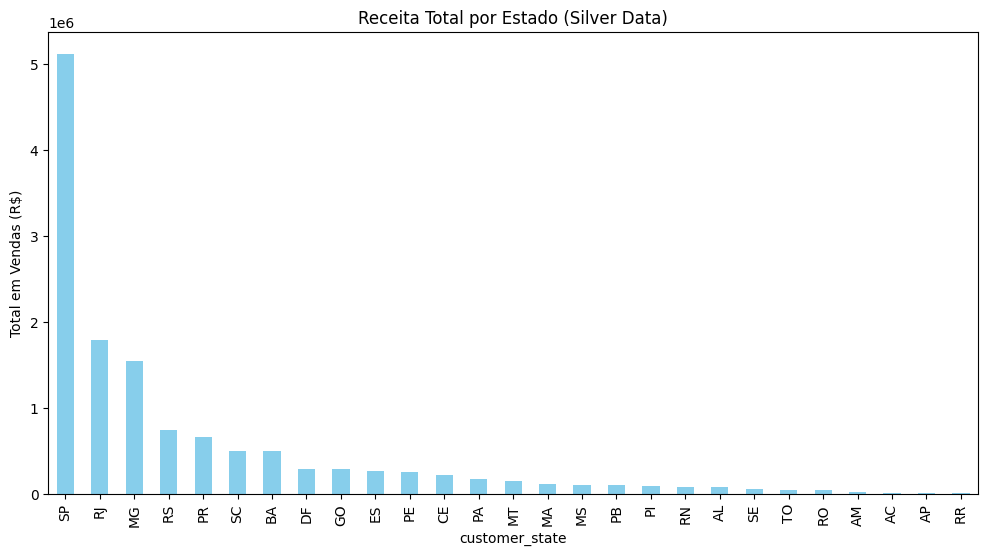

In [100]:
df_vendas = df['olist_order_items_dataset'].merge(df['olist_orders_dataset'], on='order_id')
df_vendas = df_vendas.merge(df['olist_customers_dataset'], on='customer_id')

receita_estado = df_vendas.groupby('customer_state')['price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
receita_estado.plot(kind='bar', color='skyblue')
plt.title('Receita Total por Estado (Silver Data)')
plt.ylabel('Total em Vendas (R$)')
plt.show()

## Distribuição dos Status dos Pedidos

/tmp/ipykernel_111578/3552352016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')


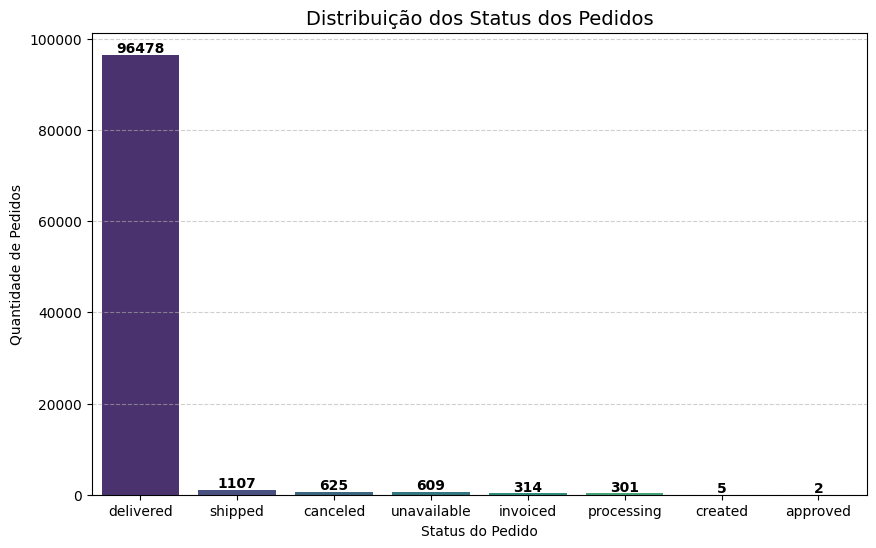

In [101]:
df_orders = df['olist_orders_dataset'].copy()

status_counts = df_orders['order_status'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')

plt.title('Distribuição dos Status dos Pedidos', fontsize=14)
plt.xlabel('Status do Pedido')
plt.ylabel('Quantidade de Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in enumerate(status_counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.xticks(rotation=0)
plt.show()

<h3>Predomínio de Entregas Concluídas</h3>
<strong>Insight:</strong> A base de dados é composta em mais de 97% por pedidos com status delivered. Isso demonstra que o ecossistema da Olist é maduro e possui um fluxo transacional saudável.

<h3>Taxa de Atrito Logístico</h3>
<strong>Insight:</strong> Os status shipped, processing e invoiced representam pedidos que ainda estão "vivos" no pipeline. Somados, eles indicam a carga de trabalho operacional pendente no momento da extração dos dados. 

<h3>Análise de Conversão e Cancelamentos</h3>
<strong>Insight:</strong> O volume de pedidos canceled é significativamente baixo. Isso indica que, uma vez que o pedido entra no sistema, a probabilidade de desistência ou falha crítica que leve ao cancelamento é mínima.

<h3>Inconsistências e Casos Atípicos</h3>
<strong>Insight:</strong> Status como created e approved com números extremamente baixos sugerem registros que ficaram "presos" em etapas iniciais por falhas sistêmicas ou de pagamento.

## Tempo Médio de Entrega por Estado

/tmp/ipykernel_111578/3732196289.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_delivery_state.values, y=avg_delivery_state.index, palette='Reds_r')


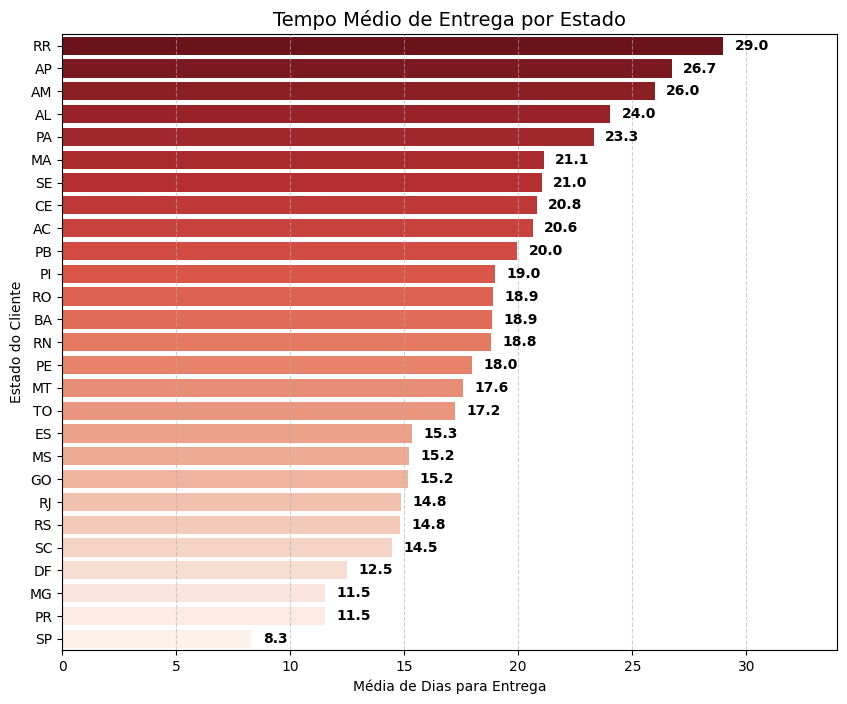

In [102]:
df_orders = df['olist_orders_dataset'].copy()

cols_data = ['order_purchase_timestamp', 'order_delivered_customer_date']
for col in cols_data:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_orders['tempo_real_dias'] = (
    df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']
).dt.days

df_clean = df_orders.dropna(subset=['tempo_real_dias'])

df_delivery_geo = pd.merge(
    df_clean, 
    df['olist_customers_dataset'][['customer_id', 'customer_state']], 
    on='customer_id'
)

avg_delivery_state = df_delivery_geo.groupby('customer_state')['tempo_real_dias'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=avg_delivery_state.values, y=avg_delivery_state.index, palette='Reds_r')

plt.title('Tempo Médio de Entrega por Estado', fontsize=14)
plt.xlabel('Média de Dias para Entrega')
plt.ylabel('Estado do Cliente')
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(avg_delivery_state.values):
    ax.text(v + 0.5, i, f'{v:.1f}', color='black', va='center', fontweight='bold')

plt.xlim(0, avg_delivery_state.max() + 5)

plt.show()

<h3>Disparidade Logística Regional</h3>
<strong>Insight:</strong> Existe uma desigualdade geográfica evidente. Estados das regiões Norte e Nordeste apresentam médias de entrega que chegam a ser 3 vezes superiores à média de São Paulo. Isso reflete os desafios de infraestrutura e a dependência de modais de transporte mais complexos para cobrir as dimensões continentais do Brasil.

<h3>Eficiência do Eixo Sul-Sudeste</h3>
<strong>Insight:</strong> Os estados de SP, PR, MG e SC ocupam a base do gráfico com os menores tempos de entrega. Como o ecossistema da Olist possui alta concentração de vendedores nestas regiões, a proximidade física reduz drasticamente as etapas de transferência de carga.

<h3>Gargalos na Região Norte</h3>
<strong>Insight:</strong> Roraima aparece como o ponto mais crítico, com 29 dias de média. No contexto de Big Data e modelagem de grafos, esses nós representam as arestas de maior latência. Esse dado sugere que, para essas localidades, o sistema de frete precisa de janelas de predição muito mais largas para evitar frustrações no consumidor final.

<h3>Estabilidade do Centro-Oeste e Nordeste Médio</h3>
<strong>Insight:</strong> Estados como PE, RN e BA apresentam uma estabilidade em torno de 18-19 dias. Isso indica que, apesar da distância, existe uma malha rodoviária e de distribuição consolidada que atende esses hubs regionais, servindo como uma base de comparação para medir a eficiência das transportadoras parceiras.

## Histograma de Atrasos

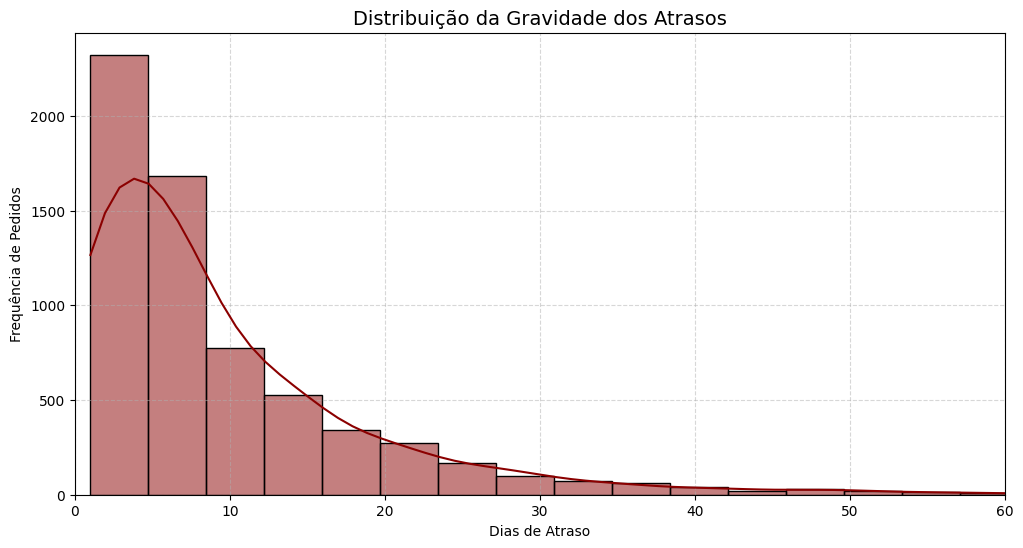

In [103]:
df_atrasos_plot = df['olist_orders_dataset'].copy()

cols_atraso = ['order_delivered_customer_date', 'order_estimated_delivery_date']
for col in cols_atraso:
    df_atrasos_plot[col] = pd.to_datetime(df_atrasos_plot[col])

df_atrasos_plot['delivery_delay_days'] = (
    df_atrasos_plot['order_delivered_customer_date'] - df_atrasos_plot['order_estimated_delivery_date']
).dt.days

df_somente_atrasos = df_atrasos_plot[df_atrasos_plot['delivery_delay_days'] > 0].dropna(subset=['delivery_delay_days'])

plt.figure(figsize=(12, 6))
sns.histplot(df_somente_atrasos['delivery_delay_days'], bins=50, kde=True, color='darkred')

plt.title('Distribuição da Gravidade dos Atrasos', fontsize=14)
plt.xlabel('Dias de Atraso')
plt.ylabel('Frequência de Pedidos')

plt.xlim(0, 60)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

<h3>Concentração em Atrasos de Curto Prazo</h3>
<strong>Insight:</strong> O gráfico revela que a grande massa de pedidos atrasados se concentra na primeira semana após o prazo estimado (pico entre 1 e 5 dias). Isso sugere que a maioria das falhas não é sistêmica, mas sim operacional, possivelmente ligada a gargalos na última milha ou tentativas de entrega malsucedidas em horários comerciais.

<h3>Comportamento de Cauda Longa</h3>
<strong>Insight:</strong> Existe uma "cauda longa" que se estende até o limite de 60 dias. Esses registros representam arestas de altíssima fricção. Para o negócio, esses casos são críticos, pois provavelmente correspondem a extravios, greves ou problemas de redespacho em áreas remotas, sendo os principais geradores de avaliações negativas.

<h3>Resiliência do Modelo de Estimativa</h3>
<strong>Insight:</strong> O decaimento acentuado da curva após os 10 dias de atraso indica que o modelo é, em geral, resiliente. A maior parte das entregas que saem do cronograma original consegue ser finalizada em um intervalo aceitável, mostrando que a malha logística possui capacidade de recuperação rápida após o vencimento do prazo inicial.

<h3>Oportunidade de Ajuste de Expectativa</h3>
<strong>Insight:</strong> A alta frequência de atrasos muito pequenos (1 a 3 dias) indica uma oportunidade de "ajuste fino" na promessa de frete. Adicionar uma margem de segurança de poucos dias nos algoritmos de cálculo de prazo poderia converter uma enorme parcela desses "pedidos atrasados" em "entregas no prazo", melhorando drasticamente a percepção de confiança do cliente na plataforma.

## Relação entre tempo estimado x tempo real

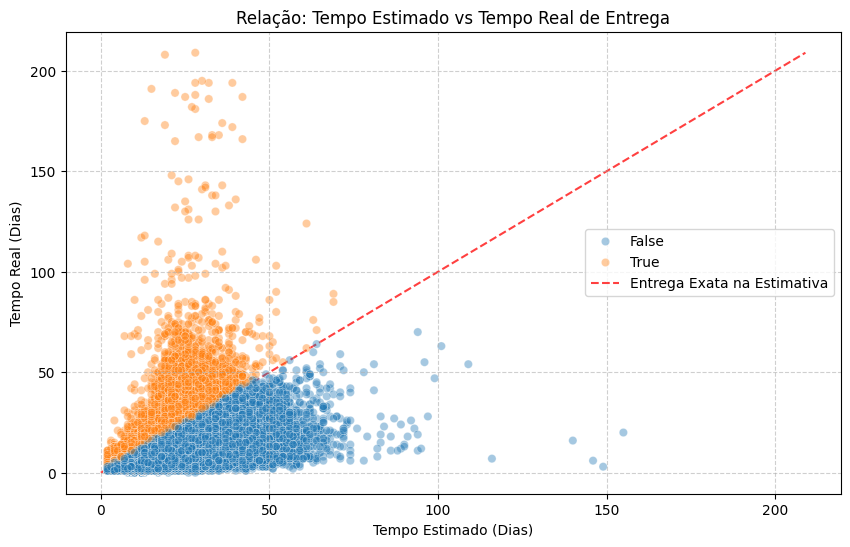

In [104]:
df_orders = df['olist_orders_dataset'].copy()

cols_data = [
    'order_purchase_timestamp', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

for col in cols_data:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_orders['tempo_real_dias'] = (
    df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']
).dt.days

df_orders['tempo_estimado_dias'] = (
    df_orders['order_estimated_delivery_date'] - df_orders['order_purchase_timestamp']
).dt.days

df_clean = df_orders.dropna(subset=['tempo_real_dias', 'tempo_estimado_dias'])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, 
    x='tempo_estimado_dias', 
    y='tempo_real_dias', 
    hue='is_late',
    alpha=0.4
)

lims = [0, max(df_clean['tempo_estimado_dias'].max(), df_clean['tempo_real_dias'].max())]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Entrega Exata na Estimativa')

plt.title('Relação: Tempo Estimado vs Tempo Real de Entrega')
plt.xlabel('Tempo Estimado (Dias)')
plt.ylabel('Tempo Real (Dias)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_111578/609109228.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


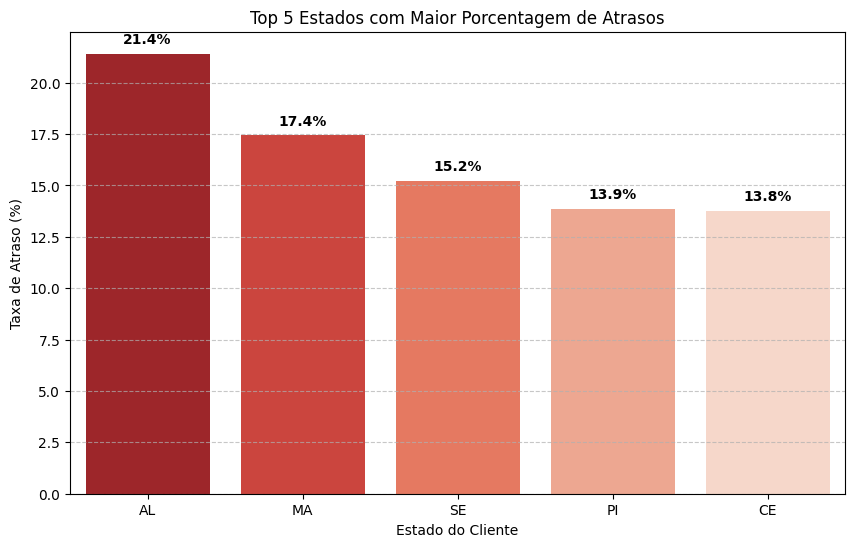

Resumo dos Top 5 Estados Críticos:
                total_pedidos  taxa_atraso_%
customer_state                              
AL                        397      21.410579
MA                        717      17.433752
SE                        335      15.223881
PI                        476      13.865546
CE                       1279      13.760751


In [105]:
df_geo_orders = pd.merge(
    df_clean, 
    df['olist_customers_dataset'][['customer_id', 'customer_state']], 
    on='customer_id'
)

atrasos_por_estado = df_geo_orders.groupby('customer_state').agg(
    total_pedidos=('is_late', 'count'),
    total_atrasos=('is_late', 'sum')
)

atrasos_por_estado['taxa_atraso_%'] = (atrasos_por_estado['total_atrasos'] / atrasos_por_estado['total_pedidos']) * 100

top_5_atrasos = atrasos_por_estado[atrasos_por_estado['total_pedidos'] > 100].sort_values('taxa_atraso_%', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_5_atrasos.index, 
    y=top_5_atrasos['taxa_atraso_%'], 
    palette='Reds_r'
)

plt.title('Top 5 Estados com Maior Porcentagem de Atrasos')
plt.ylabel('Taxa de Atraso (%)')
plt.xlabel('Estado do Cliente')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(top_5_atrasos['taxa_atraso_%']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

print("Resumo dos Top 5 Estados Críticos:")
print(top_5_atrasos[['total_pedidos', 'taxa_atraso_%']])

<h3>Eficiência da estimativa</h3>
<strong>Insight:</strong> A Olist é altamente conservadora em suas promessas. O sistema de frete calcula prazos longos para garantir que a maioria das entregas ocorra antes do limite prometido. Isso gera o "efeito surpresa positiva" no cliente, mas pode desencorajar vendas se o prazo exibido no checkout for longo demais sem necessidade.

<h3>Identificação de atrasos graves</h3>
<strong>Insight:</strong> Existem casos em que o tempo estimado era baixo (ex: 20 dias) e o tempo real passou de 100 ou 150 dias. Esses são os casos de falha crítica (extravios, greves ou problemas graves na transportadora).

<h3>Teto de entrega VS Realidade</h3>
<strong>Insight:</strong> O modelo de estimativa da Olist raramente projeta entregas para mais de 60-70 dias, mas a realidade logística (eixo Y) mostra que o "teto" real de entrega pode chegar a 200 dias em casos extremos. Isso indica que, para entregas de distância muito longa ou áreas de risco, o modelo de predição perde a acurácia.

<h3>Concentração de performance</h3>
<strong>Insight:</strong> A maioria dos clientes recebe seus produtos em aproximadamente metade do tempo prometido. Isso sugere uma folga (buffer) de segurança muito grande na estratégia de marketing de frete.

## Volume de compras por dia da semana

/tmp/ipykernel_111578/36089940.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_dia.index, y=vendas_dia.values, palette='viridis')


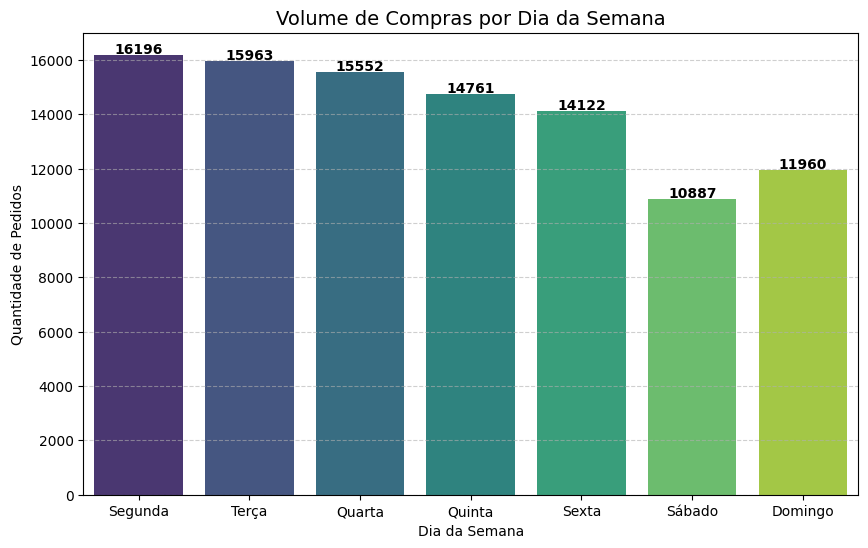

In [106]:
df_orders = df['olist_orders_dataset'].copy()
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

df_orders['dia_semana'] = df_orders['order_purchase_timestamp'].dt.day_name()

ordem_dias = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]
traduçao_dias = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta', 
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

vendas_dia = df_orders['dia_semana'].value_counts().reindex(ordem_dias)
vendas_dia.index = [traduçao_dias[d] for d in vendas_dia.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=vendas_dia.index, y=vendas_dia.values, palette='viridis')

plt.title('Volume de Compras por Dia da Semana', fontsize=14)
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in enumerate(vendas_dia.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.show()

<h3>Dia com maior volume de vendas</h3>
<strong>Insight:</strong> Segunda feira é o dia com maior volume de vendas, seguido pela terça feira. Existe um comportamento de "represa". Os consumidores pesquisam e decidem a compra durante o descanso do final de semana, mas preferem efetivar o pagamento no início da semana útil. Isso pode estar ligado à percepção de que o produto será postado mais rápido se comprado na segunda.

<h3>Declíno gradual útil</h3>
<strong>Insight:</strong> O volum cai consistentemente de Seegunda à Sexta. O senso de urgência do consumidor diminui conforme o final de semana se aproxima. Na Sexta-feira, o cliente pode evitar comprar por saber que o produto provavelmente só sairá do centro de distribuição na semana seguinte.

<h3>Dia com menor volume de vendas</h3>
<strong>Insight:</strong> Sábado é o dia com menor volume de vendas. No Sábado, o comportamento do consumidor brasileiro muda para o lazer offline ou compras presenciais. É o dia de menor engajamento com plataformas digitais de compra.

<h3>Subida nas comprar no Domingo</h3>
<strong>Insight:</strong> Domingo mostra uma subida relevante em relação ao Sábado. À noite, no domingo, começa o ciclo de planejamento da semana. O aumento no volume indica o início da curva de compras que atinge o ápice no dia seguinte.

## Percentual de pedidos com atraso por mês

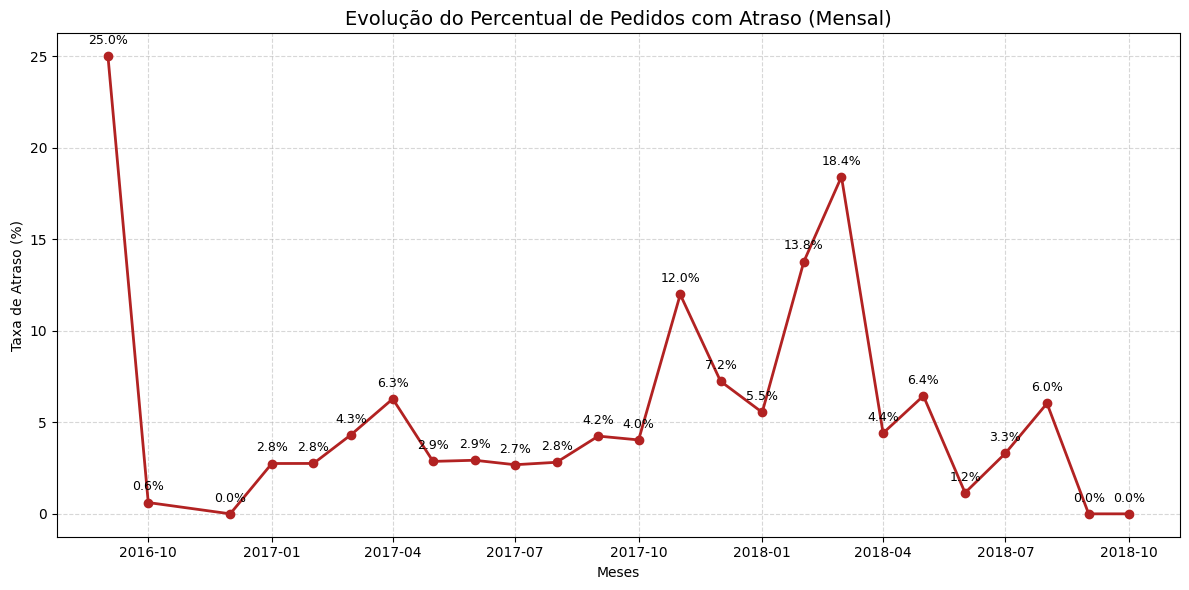

In [107]:
df_trend = df['olist_orders_dataset'].copy()
df_trend['order_purchase_timestamp'] = pd.to_datetime(df_trend['order_purchase_timestamp'])

df_trend['month_year'] = df_trend['order_purchase_timestamp'].dt.to_period('M')

monthly_delay = df_trend.groupby('month_year')['is_late'].mean() * 100

monthly_delay.index = monthly_delay.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(monthly_delay.index, monthly_delay.values, marker='o', linestyle='-', color='firebrick', linewidth=2)

plt.title('Evolução do Percentual de Pedidos com Atraso (Mensal)', fontsize=14)
plt.ylabel('Taxa de Atraso (%)')
plt.xlabel('Meses')
plt.grid(True, linestyle='--', alpha=0.5)

for x, y in zip(monthly_delay.index, monthly_delay.values):
    plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

<h3>Pico de atraso (Setembro/2016)</h3>
<strong>Insight:</strong> Geralmente, em projetos de dados como este da Olist, os primeiros meses refletem uma base de dados pequena onde qualquer atraso distorce a média, ou uma fase de teste onde os processos logísticos ainda não estavam maduros. Logo em seguida a taxa desce para quase zero, indicando uma correção rápida de rota.

<h3>Impacto da sazonalidade (Novembro/2017 a Março/2018)</h3>
<strong>Insight (Black Friday):</strong> O salto de Novembro/2017 reflete o gargalo causado pela Black Friday. O volume de vendas aumenta tanto que as transportadoras e os vendedores não conseguem dar vazão, gerando atrasos em cascata.
<strong>Insight (Pico em Março/2018):</strong> O valor de 18,4% em Março é atípico. No contexto, isso costuma estar relacionado à Greve dos Caminhoneiros ou problemas sistêmicos nos Correios. É um sinal claro de uma crise externa que paralisou a logística.

<h3>Recuperação e estabilização (pós Abril/2018)</h3>
<strong>Insight:</strong> A operação conseguiu "limpar" o estoque de pedidos atrasados e normalizar o fluxo. A partir daí, a taxa oscila em níveis mais baixos, indicando que a empresa aprendeu com os picos anteriores e melhorou o planejamento de frete.

## Tempo de aprovação de Pagamento

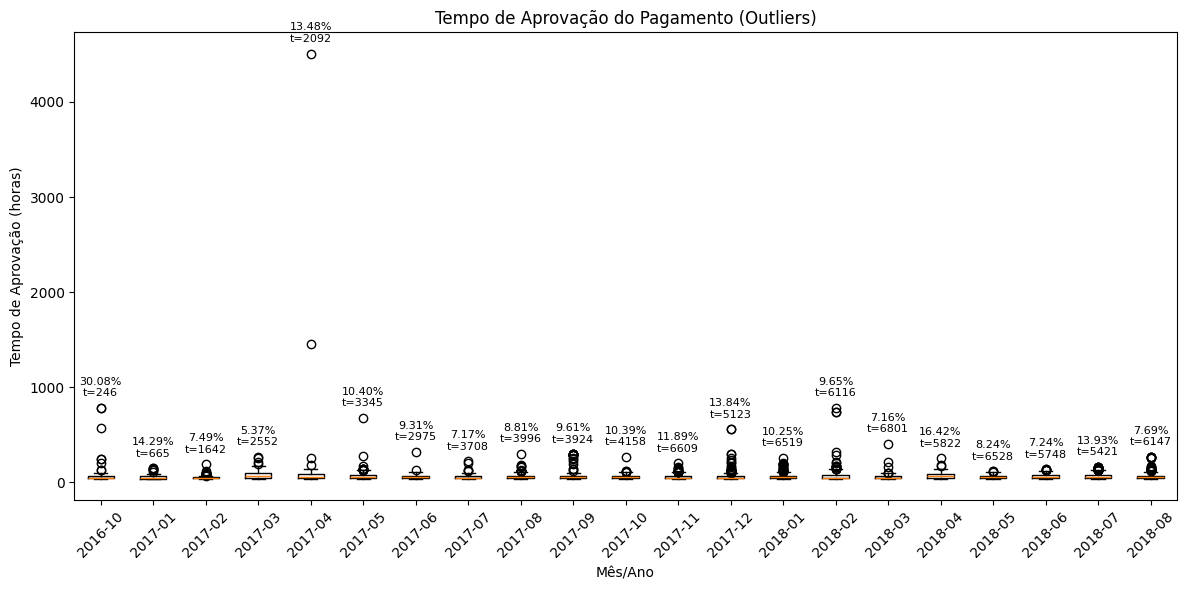

In [111]:
df_prov_time = df['olist_orders_dataset'].copy()

df_prov_time['order_purchase_timestamp'] = pd.to_datetime(df_prov_time['order_purchase_timestamp'])
df_prov_time['order_approved_at'] = pd.to_datetime(df_prov_time['order_approved_at'])

df_prov_time['order_aprov_time'] = (
    df_prov_time['order_approved_at'] - df_prov_time['order_purchase_timestamp']
)

df_prov_time['order_aprov_time_h'] = df_prov_time['order_aprov_time'].dt.total_seconds() / 3600

q1 = df_prov_time['order_aprov_time_h'].quantile(0.25)
q3 = df_prov_time['order_aprov_time_h'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_prov_time['month_year'] = df_prov_time['order_approved_at'].dt.to_period('M').astype(str)

df_prov_time_outliers = df_prov_time[
    (df_prov_time['order_aprov_time_h'] < lower_bound) |
    (df_prov_time['order_aprov_time_h'] > upper_bound)
].copy()

df_prov_time_regulars = df_prov_time[
    (df_prov_time['order_aprov_time_h'] >= lower_bound) &
    (df_prov_time['order_aprov_time_h'] <= upper_bound)
].copy()

grouped_outliers = df_prov_time_outliers.groupby('month_year')
grouped_regulars = df_prov_time_regulars.groupby('month_year')

grouped_data = [g['order_aprov_time_h'].dropna() for _, g in grouped_outliers]
labels = list(grouped_outliers.groups.keys())

out_counts = grouped_outliers.size()
reg_counts = grouped_regulars.size()

plt.figure(figsize=(12, 6))
plt.boxplot(grouped_data, tick_labels=labels)

for i, label in enumerate(labels, start=1):
    y_pos = max(grouped_data[i-1]) + 100
    out_n = out_counts.get(label, 0)
    reg_n = reg_counts.get(label, 0)
    plt.text(i, y_pos, f'{(out_n/reg_n)*100:.2f}%\nt={reg_n}', ha='center', va='bottom', fontsize=8)

plt.title('Tempo de Aprovação do Pagamento (Outliers)')
plt.xlabel('Mês/Ano')
plt.ylabel('Tempo de Aprovação (horas)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como pode ser visto pelos quartis do box plot, a maioria das aprovações são feitas quase instantaneas, em menos de um minuto, os mês certamente tem variação, mas não parecem estar relacionados com a quantidade de vendas feitas.

## Taxa de Conversão
### Pronto para Envio x Entregue

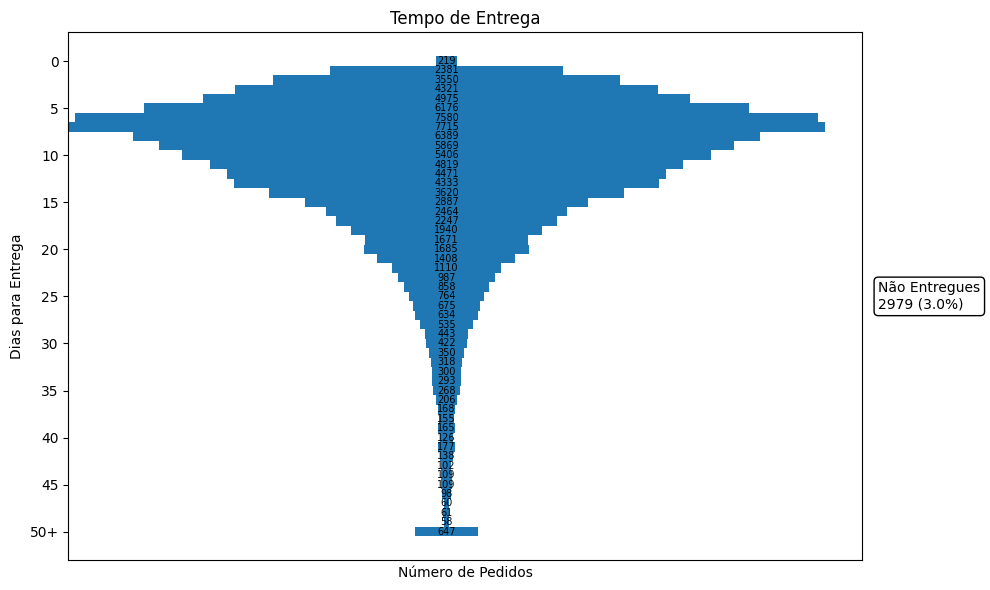

In [114]:
df_converge = df['olist_orders_dataset'].copy()

df_converge['order_approved_at'] = pd.to_datetime(df_converge['order_approved_at'])
df_converge['order_delivered_customer_date'] = pd.to_datetime(df_converge['order_delivered_customer_date'])

df_converge['days_to_arrive'] = (
    df_converge['order_delivered_customer_date'] - df_converge['order_approved_at']
).dt.days
df_plot = df_converge.copy()

df_plot['days_capped'] = df_plot['days_to_arrive'].clip(lower=0, upper=50)

counts = (
    df_plot['days_capped']
    .dropna()
    .value_counts()
    .sort_index()
)

values = counts.values
stages = counts.index.astype(int)

import numpy as np
left = (values.max() - values) / 2

labels = [str(d) if d < 50 else '50+' for d in stages]

total_orders = len(df_plot)
failed = df_plot['days_to_arrive'].isna().sum()
failed_pct = failed / total_orders * 100

plt.figure(figsize=(10, 6))
plt.barh(stages, values, left=left, height=1.0)

plt.gca().invert_yaxis()
plt.title('Tempo de Entrega')
plt.xlabel('Número de Pedidos')
plt.ylabel('Dias para Entrega')

yticks = [d for d in stages if d % 5 == 0 or d == 50]
ytick_labels = [str(d) if d < 50 else '50+' for d in yticks]

plt.yticks(yticks, ytick_labels)

for i, v in enumerate(values):
    plt.text(left[i] + v/2, stages[i], str(v), ha='center', va='center', fontsize=7, color='black', rotation=0)

plt.text(
    1.02, 0.5,
    f'Não Entregues\n{failed} ({failed_pct:.1f}%)',
    transform=plt.gca().transAxes,
    fontsize=10,
    va='center',
    bbox=dict(boxstyle='round', facecolor='white')
)
plt.xticks([])
plt.tight_layout()
plt.show()

A maioria dos pedidos são entregues entre 4 e 10 dias e entregas longas (mais de 50 dias) são uma exeção, essa taxa é menor do que o cancelamento.

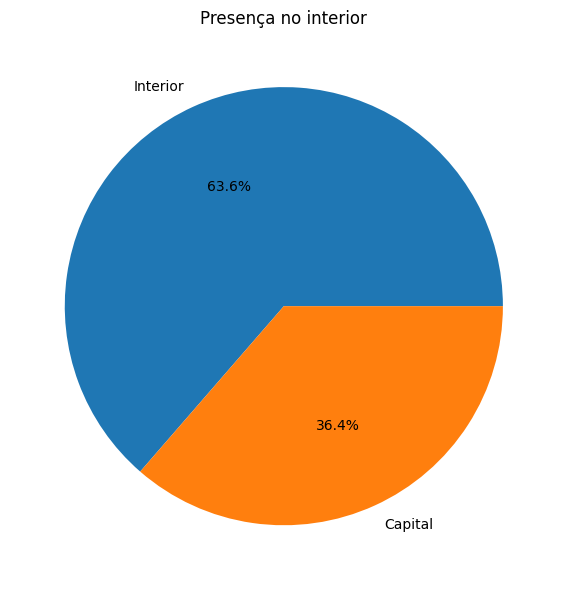

In [115]:
df_capital = df['olist_geolocation_dataset'].copy()

capitals = {
    'AC': 'rio branco', 'AL': 'maceio', 'AP': 'macapa', 'AM': 'manaus',
    'BA': 'salvador', 'CE': 'fortaleza', 'DF': 'brasilia', 'ES': 'vitoria',
    'GO': 'goiania', 'MA': 'sao luis', 'MT': 'cuiaba', 'MS': 'campo grande',
    'MG': 'belo horizonte', 'PA': 'belem', 'PB': 'joao pessoa', 'PR': 'curitiba',
    'PE': 'recife', 'PI': 'teresina', 'RJ': 'rio de janeiro', 'RN': 'natal',
    'RS': 'porto alegre', 'RO': 'porto velho', 'RR': 'boa vista',
    'SC': 'florianopolis', 'SP': 'sao paulo', 'SE': 'aracaju', 'TO': 'palmas'
}

df_capital['city_norm'] = (
    df_capital['geolocation_city']
    .str.lower()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

df_capital['is_capital'] = df_capital.apply(
    lambda x: 'Capital' if capitals.get(x['geolocation_state']) == x['city_norm'] else 'Interior',
    axis=1
)

counts = df_capital['is_capital'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')

plt.title('Presença no interior')
plt.tight_layout()
plt.show()